# Modelling

Python/Jupyter Notebook version converted from `model.Rmd`.

The original R code used `drc`, `ggplot2`, `dplyr`, and `tidyverse`. This notebook uses:

- `pandas` for data manipulation
- `numpy` for numerical work
- `scipy.optimize.curve_fit` for nonlinear curve fitting
- `matplotlib` for plotting

> Update `DATA_PATH` and `PLOT_DIR` before running.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_PATH = Path("../GSE55343_TAMRs_RNAseq_processed_data.txt")
PLOT_DIR = Path("../../5_model_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

COLUMN sample_1
MCF-750.5
clean data: csv

In [2]:
import csv

input_file  = "D:/Bio-modeling/4-project/GSE55343_TAMRs_RNAseq_processed_data.txt"
output_file = "../../../GSE55343_TAMRs_RNAseq_processed_data.csv" 

delimiter = '\t'

with open(input_file, 'r', encoding='utf-8') as txt_file:
    lines = txt_file.readlines()

with open(output_file, 'w', newline='', encoding='utf-8') as csv_file:
    writer = csv.writer(csv_file)
    for line in lines:
        row = line.strip().split(delimiter)
        writer.writerow(row)

print(f"Converted {input_file} → {output_file}")

df = pd.read_csv(output_file)

print(df.head())
print(df.dtypes)
print(df.shape)

# Filter by value in a column
filtered = [df['sample_1'] == "MCF-750.5" ]

# Drop rows with missing values
df_clean = df.dropna()

df_clean.to_csv("../GSE55343_TAMRs_RNAseq_processed_data.csv", index=False)
print("Saved cleaned data.")

Converted D:/Bio-modeling/4-project/GSE55343_TAMRs_RNAseq_processed_data.txt → ../../../GSE55343_TAMRs_RNAseq_processed_data.csv
       test_id      gene_id                       gene               locus  \
0  XLOC_000001  XLOC_000001                    DDX11L1    chr1:11873-29370   
1  XLOC_000002  XLOC_000002                      OR4F5    chr1:69090-70008   
2  XLOC_000003  XLOC_000003  LOC100132062,LOC100133331  chr1:323891-328581   
3  XLOC_000004  XLOC_000004                      OR4F3  chr1:367658-368597   
4  XLOC_000005  XLOC_000005                  LOC643837  chr1:763063-789979   

    sample_1 sample_2  status  value_1   value_2  log2(fold_change)  \
0  MCF-7S0.5   TAMR-1  NOTEST  0.01389  0.054678       1.976870e+00   
1  MCF-7S0.5   TAMR-1  NOTEST  0.00000  0.000000       0.000000e+00   
2  MCF-7S0.5   TAMR-1      OK  2.77120  3.773420       4.453640e-01   
3  MCF-7S0.5   TAMR-1  NOTEST  0.00000  0.072155      1.797690e+308   
4  MCF-7S0.5   TAMR-1      OK  4.06948  4.08285

In [21]:
df = df_clean[df_clean['sample_1'] == "MCF-7S0.5"]

In [22]:
# Load and prepare data
#  = pd.read_csv("../GSE55343_TAMRs_RNAseq_processed_data.csv")
module_table = df
module_table["sample_2"] = module_table["sample_2"].replace({
    "TAMR-1": 1,
    "TAMR-4": 4,
    "TAMR-7": 7,
    "TAMR-8": 8,
})

module_table.head()

C:\Users\lwy\AppData\Local\Temp\ipykernel_20300\4005176075.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  module_table["sample_2"] = module_table["sample_2"].replace({


,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant
0,XLOC_000001,XLOC_000001,DDX11L1,chr1:11873-29370,MCF-7S0.5,1,NOTEST,0.01389,0.054678,1.976870e+00,-1.223600e-01,0.902614,1.000000,no
1,XLOC_000002,XLOC_000002,OR4F5,chr1:69090-70008,MCF-7S0.5,1,NOTEST,0.00000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.000000,no
2,XLOC_000003,XLOC_000003,"LOC100132062,LOC100133331",chr1:323891-328581,MCF-7S0.5,1,OK,2.77120,3.773420,4.453640e-01,-5.450590e-01,0.585713,0.999988,no
3,XLOC_000004,XLOC_000004,OR4F3,chr1:367658-368597,MCF-7S0.5,1,NOTEST,0.00000,0.072155,1.797690e+308,1.797690e+308,0.306933,1.000000,no
4,XLOC_000005,XLOC_000005,LOC643837,chr1:763063-789979,MCF-7S0.5,1,OK,4.06948,4.082850,4.729950e-03,-4.459620e-03,0.996442,0.999988,no


## Model definitions

These functions reproduce the main dose-response forms used in the R notebook.

In [56]:
def ll4(x, b, c, d, e):
    """Four-parameter log-logistic model."""
    x = np.asarray(x, dtype=float)
    return c + (d - c) / (1.0 + np.exp(b * (np.log(x) - np.log(e))))


def ll5(x, b, c, d, e, f):
    """Five-parameter log-logistic model."""
    x = np.asarray(x, dtype=float)
    return c + (d - c) / (1.0 + np.exp(b * (np.log(x) - np.log(e)))) ** f


def weibull1_4(x, b, c, d, e):
    """Four-parameter Weibull type-1 model."""
    x = np.asarray(x, dtype=float)
    return c + (d - c) * np.exp(-np.exp(b * (np.log(x) - np.log(e))))


def modified_weibull1_4(x, b, c, d, e, shift=5.0):
    """Weibull type-1 model using log(x + shift)."""
    x = np.asarray(x, dtype=float)
    return c + (d - c) * np.exp(-np.exp(b * (np.log(x + shift) - e)))

def mm2(x, d, e):
    x = np.asarray(x, dtype=float)
    return d / (1.0 + e / x)

def mm3(dose, c, d, e):
    dose = np.asarray(dose, dtype=float)
    return c + (d - c) / (1.0 + e / dose)

def ll3(dose, b, d, e):
    dose = np.asarray(dose, dtype=float)
    return d / (1.0 + np.exp(b * (np.log(dose) - np.log(e))))

MODEL_FUNCTIONS = {
    "MM2": mm2,
    "MM3": mm3,
    "LL.3": ll3,
    "LL.4": ll4,
    "LL.5": ll5,
    "W1.4": weibull1_4,
    "modified_W1.4": modified_weibull1_4,
}

In [57]:
def _initial_guess(x, y, model_name):
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    e0 = float(np.nanmedian(x))

    if model_name == "LL.5":
        return [1.0, y_min, y_max, e0, 1.0]
    if model_name == "modified_W1.4":
        return [1.0, y_min, y_max, float(np.log(e0 + 5.0))]
    if model_name == "MM3":
        return [y_min, y_max, e0]          # c, d, e  (3 params)
    if model_name == "MM2":
        return [y_max, e0]                 # d, e     (2 params)
    if model_name == "LL.3":
        return [1.0, y_max, e0]            # b, d, e  (3 params)
    return [1.0, y_min, y_max, e0]         # default: 4-param models


def fit_nonlinear_model(x, y, model_name="LL.5", maxfev=100000):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]

    if len(x) < 3:
        raise ValueError("At least three valid observations are required.")
    if np.any(x <= 0) and model_name != "modified_W1.4":
        raise ValueError(f"{model_name} requires positive x values because log(x) is used.")

    func = MODEL_FUNCTIONS[model_name]
    p0 = _initial_guess(x, y, model_name)
    params, covariance = curve_fit(func, x, y, p0=p0, maxfev=maxfev)
    return {
        "model_name": model_name,
        "function": func,
        "params": params,
        "covariance": covariance,
    }


def predict_model(fitted_model, x):
    return fitted_model["function"](np.asarray(x, dtype=float), *fitted_model["params"])


def r_squared(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot


def model_equation(model_name, params, x_name="X", y_name="Y"):
    p = np.round(params, 4)
    if model_name == "LL.4":
        b, c, d, e = p
        return f"{y_name} = {c} + ({d} - {c}) / (1 + exp({b} * (log({x_name}) - log({e}))))"
    if model_name == "LL.5":
        b, c, d, e, f = p
        return f"{y_name} = {c} + ({d} - {c}) / (1 + exp({b} * (log({x_name}) - log({e}))))^{f}"
    if model_name == "W1.4":
        b, c, d, e = p
        return f"{y_name} = {c} + ({d} - {c}) * exp(-exp({b} * (log({x_name}) - log({e}))))"
    if model_name == "modified_W1.4":
        b, c, d, e = p
        return f"{y_name} = {c} + ({d} - {c}) * exp(-exp({b} * (log({x_name} + 5) - {e})))"
    if model_name == "MM3":
        c, d, e = p
        return f"{y_name} = {c} + ({d} - {c}) / (1 + {e} / {x_name})"
    if model_name == "MM2":
        d, e = p
        return f"{y_name} = {d} / (1 + {e} / {x_name})"
    if model_name == "LL.3":
        b, d, e = p
        return f"{y_name} = {d} / (1 + exp({b} * (log({x_name}) - log({e}))))"
    return "Unknown model type"

## Basic dose-response example

In [13]:
module_table["gene"].str.startswith("AKT")

0         False
1         False
2         False
3         False
4         False
          ...  
251525    False
251526    False
251527    False
251528    False
251529    False
Name: gene, Length: 251530, dtype: bool

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


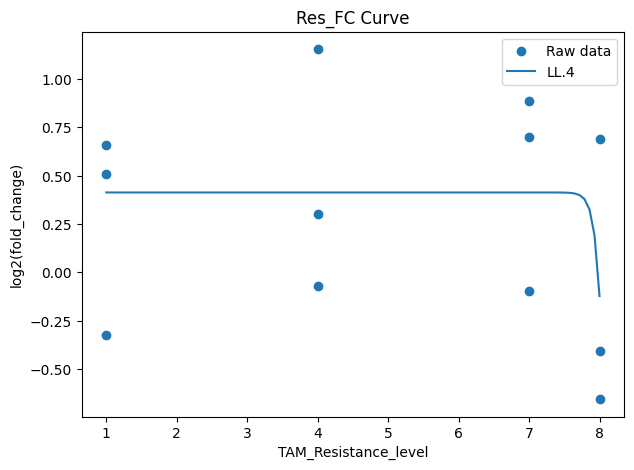

In [27]:
KE = module_table.loc[
    module_table["gene"].isin(["AKT1", "AKT2", "AKT3"])
].copy()


model_AKT = fit_nonlinear_model(KE["sample_2"], KE["log2(fold_change)"], model_name="LL.4")
dose_seq = np.linspace(KE["sample_2"].min(), KE["sample_2"].max(), 100)
predicted = predict_model(model_AKT, dose_seq)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(KE["sample_2"], KE["log2(fold_change)"], label="Raw data")
ax.plot(dose_seq, predicted, label= "LL.4")
ax.set(title="Res_FC Curve", xlabel="TAM_Resistance_level", ylabel="log2(fold_change)")
ax.legend()
plt.show()

## Reusable dose-response analysis

In [46]:
def dose_response_analysis(
    model_name,
    gene,
    data=df,
    log_x=True,
    ax=None,
):
    if isinstance(gene, list):
        KE = data.loc[data["gene"].isin(gene)].copy()
    else:
        KE = data.loc[data["gene"] == gene].copy()

    data_summary = (
        KE.groupby("sample_2")["log2(fold_change)"]
        .agg(mean_response="mean", sd_response="std", n="count")
        .reset_index()
    )
    data_summary["y_err"] = data_summary["sd_response"] / np.sqrt(data_summary["n"])

    fitted = fit_nonlinear_model(KE["sample_2"], KE["log2(fold_change)"], model_name=model_name)
    fitted_values = predict_model(fitted, KE["sample_2"])
    r2 = r_squared(KE["log2(fold_change)"], fitted_values)
    equation = model_equation(model_name, fitted["params"])

    dose_seq = np.linspace(KE["sample_2"].min(), KE["sample_2"].max(), 200)
    curve = predict_model(fitted, dose_seq)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(KE["sample_2"], KE["log2(fold_change)"], label="Raw data")
    ax.errorbar(
        data_summary["sample_2"],
        data_summary["mean_response"],
        yerr=data_summary["y_err"],
        fmt="none",
        capsize=3,
    )
    ax.plot(dose_seq, curve, label=f"{model_name} fit")
    if log_x:
        ax.set_xscale("log")
    ax.set(
        title=f"Response To TAM: {gene}",
        xlabel="TAM_resistance_level",
        ylabel="Log2FC",
    )
    ax.text(0.02, 0.02, f"R² = {r2:.4f}\n{equation}", transform=ax.transAxes, fontsize=9)
    ax.legend()
    plt.show()

    print(KE)
    print(f"R-squared: {r2:.4f}")
    print(f"Model equation: {equation}")

    return {
        "model": fitted,
        "equation": equation,
        "r_squared": r2,
        "data": KE,
        "summary": data_summary,
        "figure": ax.figure,
        "axis": ax,
    }

In [45]:
df["gene"].isin(["AKT1", "AKT2", "AKT3"])

0         False
1         False
2         False
3         False
4         False
          ...  
176066    False
176067    False
176068    False
176069    False
176070    False
Name: gene, Length: 100612, dtype: bool

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


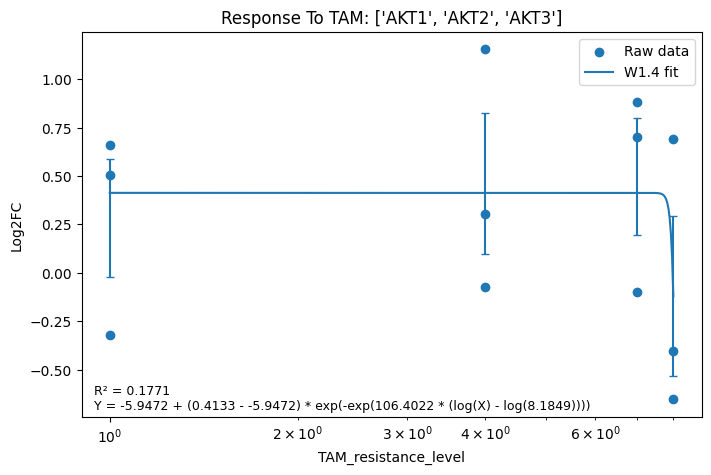

            test_id      gene_id  gene                      locus   sample_1  \
2282    XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
7160    XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
12008   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
27435   XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
32313   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
37161   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
77741   XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
82619   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
87467   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
153200  XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
158078  XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
162926  XLOC_012009  XLOC_012009  AKT2  

KeyError: 'AKT'

In [47]:
result_AKT = dose_response_analysis(
    "W1.4",
    ["AKT1", "AKT2", "AKT3"],
    df,
    log_x=True,
    ax=None,
)

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


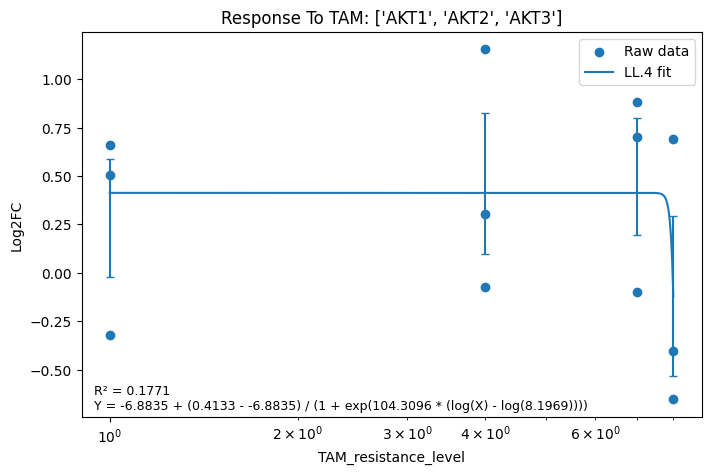

            test_id      gene_id  gene                      locus   sample_1  \
2282    XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
7160    XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
12008   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
27435   XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
32313   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
37161   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
77741   XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
82619   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
87467   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
153200  XLOC_002283  XLOC_002283  AKT3   chr1:243287729-244006886  MCF-7S0.5   
158078  XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
162926  XLOC_012009  XLOC_012009  AKT2  

In [48]:
result_AKT = dose_response_analysis(
    "LL.4",
    ["AKT1", "AKT2", "AKT3"],
    df,
    log_x=True,
    ax=None,
)

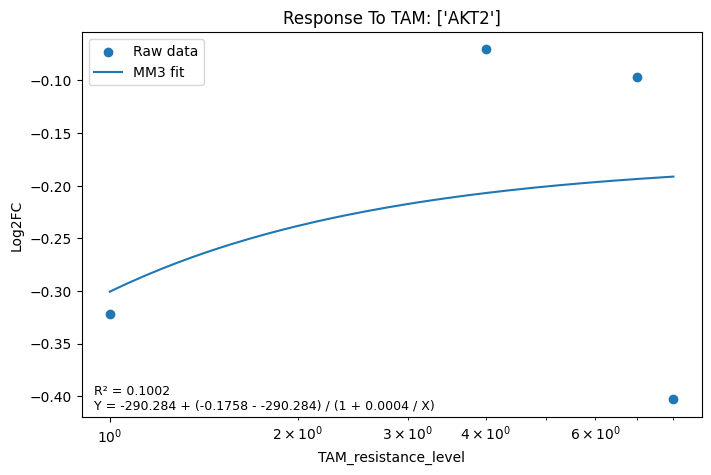

            test_id      gene_id  gene                    locus   sample_1  \
12008   XLOC_012009  XLOC_012009  AKT2  chr19:40736223-40791302  MCF-7S0.5   
37161   XLOC_012009  XLOC_012009  AKT2  chr19:40736223-40791302  MCF-7S0.5   
87467   XLOC_012009  XLOC_012009  AKT2  chr19:40736223-40791302  MCF-7S0.5   
162926  XLOC_012009  XLOC_012009  AKT2  chr19:40736223-40791302  MCF-7S0.5   

        sample_2 status  value_1  value_2  log2(fold_change)  test_stat  \
12008          1     OK  15.5983  12.4766          -0.322163   0.597699   
37161          4     OK  15.5983  14.8533          -0.070607   0.124024   
87467          7     OK  15.5983  14.5859          -0.096818   0.169832   
162926         8     OK  15.5983  11.7959          -0.403101   0.691085   

         p_value   q_value significant  
12008   0.550041  0.999988          no  
37161   0.901296  0.999988          no  
87467   0.865142  0.999988          no  
162926  0.489512  0.999988          no  
R-squared: 0.1002
Model equa

In [65]:
result_AKT = dose_response_analysis(
    "MM3",
    ["AKT2"],
    df,
    log_x=True,
    ax=None,
)

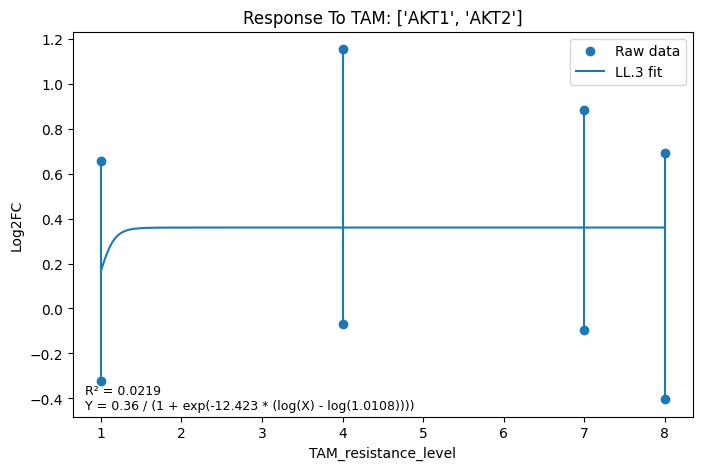

            test_id      gene_id  gene                      locus   sample_1  \
7160    XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
12008   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
32313   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
37161   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
82619   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
87467   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
158078  XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
162926  XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   

        sample_2 status  value_1   value_2  log2(fold_change)  test_stat  \
7160           1     OK  48.7915   76.9928           0.658093  -1.181160   
12008          1     OK  15.5983   12.4766          -0.322163   0.597699   
32313          4     OK  48.7915  108.5740         

In [70]:
result_AKT = dose_response_analysis(
    "LL.3",
    ["AKT1","AKT2"],
    df,
    log_x=False,
    ax=None,
)

AKT3: brain + nerves, exluded

In [92]:
targets = {
    "RTK":  "RTK",
    "PIP": "PIP",
    "PDK1": "PDK1",
    "ERK":  "ERK",
    "MEK":  "MEK",
    "P53":  "P53",
    "MTOR": "TOR",
    "P21":  "P21",
    "AKT": "AKT",
    "PI3K": "PI3K",
    "PTEN":"PTEN"
}

for name, prefix in targets.items():
    matches = df[df["gene"].str.startswith(prefix)]["gene"].unique()
    print(f"{name}: {matches}")

RTK: ['RTKN2' 'RTKN']
PIP: ['PIP5K1A' 'PIP4K2A' 'PIPSL' 'PIP4K2C' 'PIPOX' 'PIP4K2B' 'PIP5K1C'
 'PIP5K1P1' 'PIP' 'PIP5K1B' 'PIP5KL1']
PDK1: ['PDK2' 'PDK1' 'PDK4' 'PDK3']
ERK: []
MEK: []
P53: []
MTOR: ['TOR3A' 'TOR1AIP1' 'TOR1AIP2' 'TOR1B' 'TOR2A' 'TOR1A']
P21: []
AKT: ['AKT3' 'AKT1' 'AKTIP' 'AKT2' 'AKT1S1']
PI3K: []
PTEN: ['PTEN' 'PTENP1']


In [97]:
targets = {
    "RTK":   ["EGFR", "ERBB2", "ERBB3", "FGFR1", "FGFR2", "IGF1R", "MET"],
    "PIP2":  [],          # PIP2 is a lipid, not a gene
    "PIP3":  [],  # PIP3 is a lipid, not a gene
    "PDK1":  ["PDK1", "PDPK1"],           # PDPK1 is the canonical PDK1
    "ERK":   ["MAPK1", "MAPK3"],   # ERK1=MAPK3, ERK2=MAPK1
    "MEK":   ["MAP2K1", "MAP2K2"],        # MEK1=MAP2K1, MEK2=MAP2K2
    "P53":   ["TP53"],    # P53 gene is TP53
    "MTOR":  ["MTOR"],
    "P21":   ["CDKN1A"],        # P21=CDKN1A, P27=CDKN1B
    "AKT":   ["AKT1", "AKT2", "AKT3"],
    "PI3K":  ["PIK3CA", "PIK3CB", "PIK3CD", "PIK3CG", "PIK3R1", "PIK3R2"],
    "PTEN":  ["PTEN"],
}

for name, gene_list in targets.items():
    matches = df[df["gene"].isin(gene_list)]["gene"].unique()
    print(f"{name}: {matches}")

RTK: ['FGFR2' 'ERBB3' 'IGF1R' 'ERBB2' 'EGFR' 'MET' 'FGFR1']
PIP2: []
PIP3: []
PDK1: ['PDPK1' 'PDK1']
ERK: ['MAPK3' 'MAPK1']
MEK: ['MAP2K1' 'MAP2K2']
P53: ['TP53']
MTOR: ['MTOR']
P21: ['CDKN1A']
AKT: ['AKT3' 'AKT1' 'AKT2']
PI3K: ['PIK3CD' 'PIK3CA' 'PIK3CB' 'PIK3R1' 'PIK3CG']
PTEN: ['PTEN']


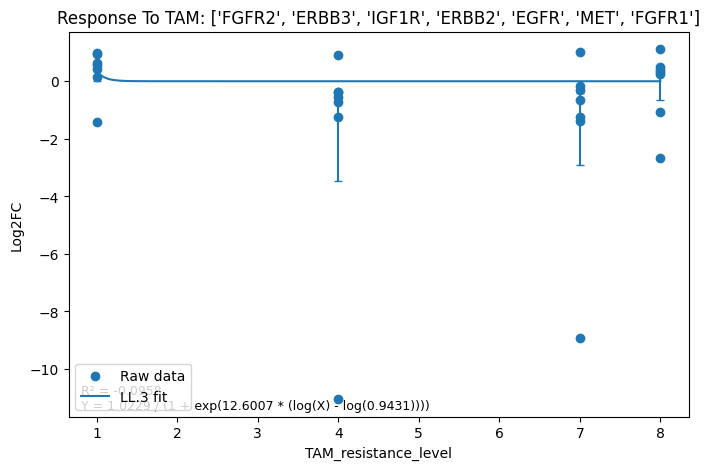

            test_id      gene_id   gene                      locus   sample_1  \
3272    XLOC_003273  XLOC_003273  FGFR2  chr10:123237843-123357972  MCF-7S0.5   
5074    XLOC_005075  XLOC_005075  ERBB3    chr12:56473808-56497291  MCF-7S0.5   
7622    XLOC_007623  XLOC_007623  IGF1R    chr15:99192760-99507759  MCF-7S0.5   
9294    XLOC_009295  XLOC_009295  ERBB2    chr17:37844392-37884915  MCF-7S0.5   
21157   XLOC_021158  XLOC_021158   EGFR     chr7:55086724-55275031  MCF-7S0.5   
21377   XLOC_021378  XLOC_021378    MET   chr7:116312458-116438440  MCF-7S0.5   
22676   XLOC_022677  XLOC_022677  FGFR1     chr8:38268655-38326352  MCF-7S0.5   
28425   XLOC_003273  XLOC_003273  FGFR2  chr10:123237843-123357972  MCF-7S0.5   
30227   XLOC_005075  XLOC_005075  ERBB3    chr12:56473808-56497291  MCF-7S0.5   
32775   XLOC_007623  XLOC_007623  IGF1R    chr15:99192760-99507759  MCF-7S0.5   
34447   XLOC_009295  XLOC_009295  ERBB2    chr17:37844392-37884915  MCF-7S0.5   
46310   XLOC_021158  XLOC_02

In [98]:
RTK = ['FGFR2','ERBB3', 'IGF1R', 'ERBB2', 'EGFR', 'MET', 'FGFR1']
result_RTK = dose_response_analysis(
    "LL.3",
    RTK,
    df,
    log_x=False,
    ax=None,
)

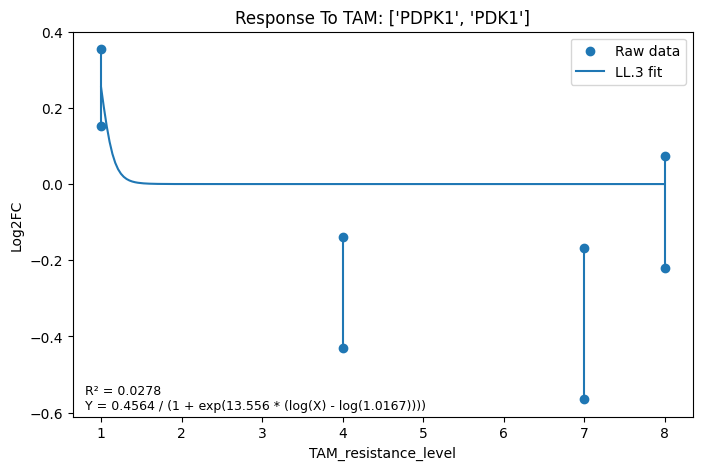

            test_id      gene_id   gene                     locus   sample_1  \
8114    XLOC_008115  XLOC_008115  PDPK1     chr16:2587969-2653189  MCF-7S0.5   
12888   XLOC_012889  XLOC_012889   PDK1  chr2:173420739-173463862  MCF-7S0.5   
33267   XLOC_008115  XLOC_008115  PDPK1     chr16:2587969-2653189  MCF-7S0.5   
38041   XLOC_012889  XLOC_012889   PDK1  chr2:173420739-173463862  MCF-7S0.5   
83573   XLOC_008115  XLOC_008115  PDPK1     chr16:2587969-2653189  MCF-7S0.5   
88347   XLOC_012889  XLOC_012889   PDK1  chr2:173420739-173463862  MCF-7S0.5   
159032  XLOC_008115  XLOC_008115  PDPK1     chr16:2587969-2653189  MCF-7S0.5   
163806  XLOC_012889  XLOC_012889   PDK1  chr2:173420739-173463862  MCF-7S0.5   

        sample_2 status   value_1   value_2  log2(fold_change)  test_stat  \
8114           1     OK  10.55530  13.49530           0.354486  -0.597901   
12888          1     OK   4.79361   5.32942           0.152866  -0.218230   
33267          4     OK  10.55530   9.59277     

In [99]:
PDK1= ['PDPK1','PDK1']

result_PDK1 = dose_response_analysis(
    "LL.3",
    PDK1,
    df,
    log_x=False,
    ax=None,
)

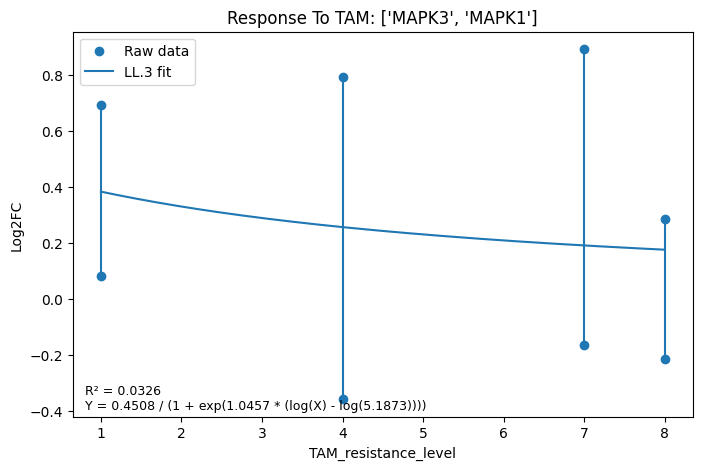

            test_id      gene_id   gene                    locus   sample_1  \
8738    XLOC_008739  XLOC_008739  MAPK3  chr16:30125425-30134630  MCF-7S0.5   
15196   XLOC_015197  XLOC_015197  MAPK1  chr22:22113946-22221970  MCF-7S0.5   
33891   XLOC_008739  XLOC_008739  MAPK3  chr16:30125425-30134630  MCF-7S0.5   
40349   XLOC_015197  XLOC_015197  MAPK1  chr22:22113946-22221970  MCF-7S0.5   
84197   XLOC_008739  XLOC_008739  MAPK3  chr16:30125425-30134630  MCF-7S0.5   
90655   XLOC_015197  XLOC_015197  MAPK1  chr22:22113946-22221970  MCF-7S0.5   
159656  XLOC_008739  XLOC_008739  MAPK3  chr16:30125425-30134630  MCF-7S0.5   
166114  XLOC_015197  XLOC_015197  MAPK1  chr22:22113946-22221970  MCF-7S0.5   

        sample_2 status  value_1  value_2  log2(fold_change)  test_stat  \
8738           1     OK  35.4071  57.1516           0.690755  -1.202640   
15196          1     OK  24.6343  26.0746           0.081973  -0.119051   
33891          4     OK  35.4071  61.2682           0.791101  -

In [100]:
ERK = ['MAPK3', 'MAPK1']
result_ERK = dose_response_analysis(
    "LL.3",
    ERK,
    df,
    log_x=False,
    ax=None,
)

d:\RDKit\envs\ml_env\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


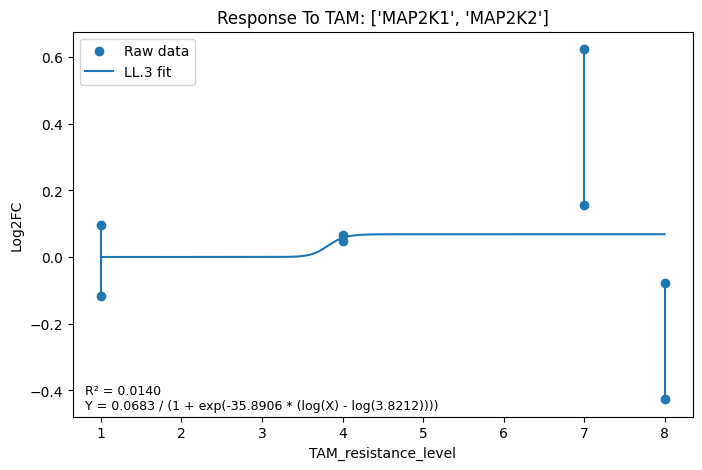

            test_id      gene_id    gene                    locus   sample_1  \
7454    XLOC_007455  XLOC_007455  MAP2K1  chr15:66679210-66790327  MCF-7S0.5   
11660   XLOC_011661  XLOC_011661  MAP2K2    chr19:4090310-4124126  MCF-7S0.5   
32607   XLOC_007455  XLOC_007455  MAP2K1  chr15:66679210-66790327  MCF-7S0.5   
36813   XLOC_011661  XLOC_011661  MAP2K2    chr19:4090310-4124126  MCF-7S0.5   
82913   XLOC_007455  XLOC_007455  MAP2K1  chr15:66679210-66790327  MCF-7S0.5   
87119   XLOC_011661  XLOC_011661  MAP2K2    chr19:4090310-4124126  MCF-7S0.5   
158372  XLOC_007455  XLOC_007455  MAP2K1  chr15:66679210-66790327  MCF-7S0.5   
162578  XLOC_011661  XLOC_011661  MAP2K2    chr19:4090310-4124126  MCF-7S0.5   

        sample_2 status  value_1   value_2  log2(fold_change)  test_stat  \
7454           1     OK  12.2623  11.29980          -0.117930   0.173354   
11660          1     OK  54.3819  58.07500           0.094791  -0.166009   
32607          4     OK  12.2623  12.84230         

In [101]:
MEK= ['MAP2K1', 'MAP2K2']
result_MTOR = dose_response_analysis(
    "LL.3",
    MEK,
    df,
    log_x=False,
    ax=None,
)

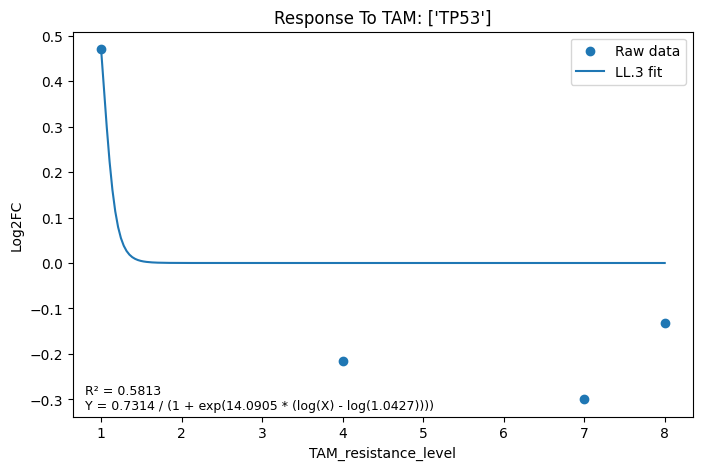

            test_id      gene_id  gene                  locus   sample_1  \
9725    XLOC_009726  XLOC_009726  TP53  chr17:7571719-7606820  MCF-7S0.5   
34878   XLOC_009726  XLOC_009726  TP53  chr17:7571719-7606820  MCF-7S0.5   
85184   XLOC_009726  XLOC_009726  TP53  chr17:7571719-7606820  MCF-7S0.5   
160643  XLOC_009726  XLOC_009726  TP53  chr17:7571719-7606820  MCF-7S0.5   

        sample_2 status  value_1  value_2  log2(fold_change)  test_stat  \
9725           1     OK  45.3538  62.8386           0.470427  -0.787492   
34878          4     OK  45.3538  39.0555          -0.215697   0.333123   
85184          7     OK  45.3538  36.8572          -0.299279   0.477879   
160643         8     OK  45.3538  41.3665          -0.132762   0.220487   

         p_value   q_value significant  
9725    0.430994  0.999988          no  
34878   0.739041  0.999988          no  
85184   0.632736  0.999988          no  
160643  0.825492  0.999988          no  
R-squared: 0.5813
Model equation: Y = 

In [102]:
P53= ['TP53']
result_MTOR = dose_response_analysis(
    "LL.3",
    P53,
    df,
    log_x=False,
    ax=None,
)

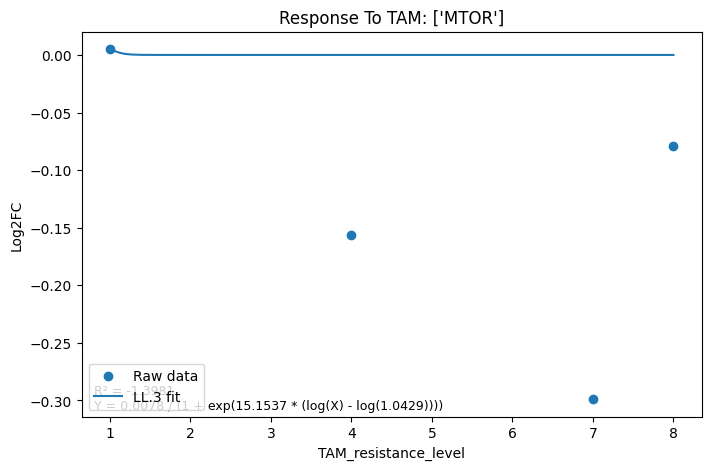

            test_id      gene_id  gene                   locus   sample_1  \
1267    XLOC_001268  XLOC_001268  MTOR  chr1:11166587-11322608  MCF-7S0.5   
26420   XLOC_001268  XLOC_001268  MTOR  chr1:11166587-11322608  MCF-7S0.5   
76726   XLOC_001268  XLOC_001268  MTOR  chr1:11166587-11322608  MCF-7S0.5   
152185  XLOC_001268  XLOC_001268  MTOR  chr1:11166587-11322608  MCF-7S0.5   

        sample_2 status  value_1  value_2  log2(fold_change)  test_stat  \
1267           1     OK  6.56779  6.59101           0.005091  -0.009185   
26420          4     OK  6.56779  5.89214          -0.156616   0.287325   
76726          7     OK  6.56779  5.33878          -0.298898   0.526951   
152185         8     OK  6.56779  6.21834          -0.078878   0.144998   

         p_value   q_value significant  
1267    0.992671  0.999988          no  
26420   0.773864  0.999988          no  
76726   0.598228  0.999988          no  
152185  0.884713  0.999988          no  
R-squared: -1.3981
Model equation

In [103]:
MTOR = ['MTOR']
result_MTOR = dose_response_analysis(
    "LL.3",
    MTOR,
    df,
    log_x=False,
    ax=None,
)

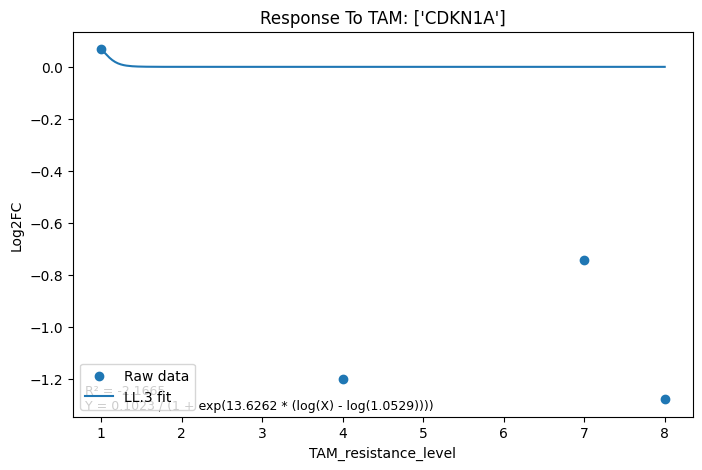

            test_id      gene_id    gene                   locus   sample_1  \
18897   XLOC_018898  XLOC_018898  CDKN1A  chr6:36644236-36655116  MCF-7S0.5   
44050   XLOC_018898  XLOC_018898  CDKN1A  chr6:36644236-36655116  MCF-7S0.5   
94356   XLOC_018898  XLOC_018898  CDKN1A  chr6:36644236-36655116  MCF-7S0.5   
169815  XLOC_018898  XLOC_018898  CDKN1A  chr6:36644236-36655116  MCF-7S0.5   

        sample_2 status  value_1   value_2  log2(fold_change)  test_stat  \
18897          1     OK  102.155  107.1160           0.068414  -0.121017   
44050          4     OK  102.155   44.4285          -1.201200   2.132440   
94356          7     OK  102.155   60.9843          -0.744248   1.300100   
169815         8     OK  102.155   42.0924          -1.279130   2.270800   

         p_value   q_value significant  
18897   0.903677  0.999988          no  
44050   0.032971  0.762157          no  
94356   0.193567  0.999988          no  
169815  0.023159  0.661958          no  
R-squared: -2.1665

In [104]:
P21= ['CDKN1A']
result_P21 = dose_response_analysis(
    "LL.3",
    P21,
    df,
    log_x=False,
    ax=None,
)

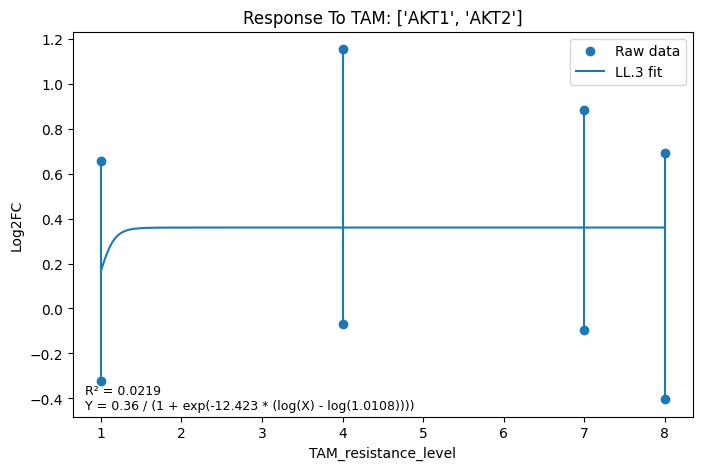

            test_id      gene_id  gene                      locus   sample_1  \
7160    XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
12008   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
32313   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
37161   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
82619   XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
87467   XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   
158078  XLOC_007161  XLOC_007161  AKT1  chr14:105235686-105262080  MCF-7S0.5   
162926  XLOC_012009  XLOC_012009  AKT2    chr19:40736223-40791302  MCF-7S0.5   

        sample_2 status  value_1   value_2  log2(fold_change)  test_stat  \
7160           1     OK  48.7915   76.9928           0.658093  -1.181160   
12008          1     OK  15.5983   12.4766          -0.322163   0.597699   
32313          4     OK  48.7915  108.5740         

In [107]:
AKT= ['AKT1','AKT2']
result_AKT = dose_response_analysis(
    "LL.3",
    AKT,
    df,
    log_x=False,
    ax=None,
)

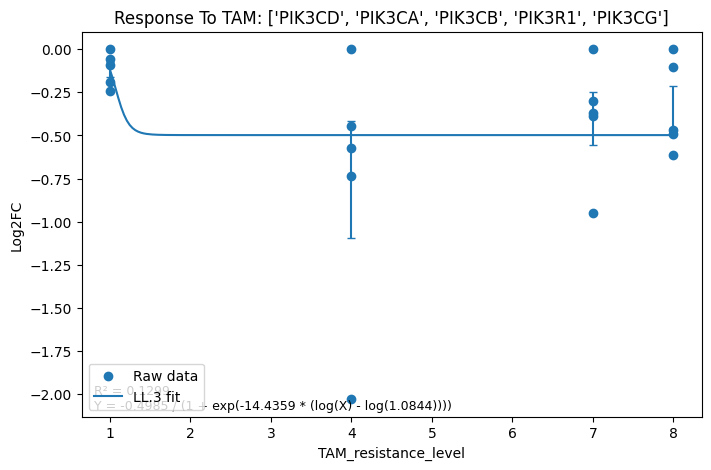

            test_id      gene_id    gene                     locus   sample_1  \
71      XLOC_000072  XLOC_000072  PIK3CD      chr1:9711789-9884550  MCF-7S0.5   
15955   XLOC_015956  XLOC_015956  PIK3CA  chr3:178866266-178954915  MCF-7S0.5   
16458   XLOC_016459  XLOC_016459  PIK3CB  chr3:138371539-138553749  MCF-7S0.5   
17735   XLOC_017736  XLOC_017736  PIK3R1    chr5:67511547-67597649  MCF-7S0.5   
21357   XLOC_021358  XLOC_021358  PIK3CG  chr7:106505923-106547592  MCF-7S0.5   
25224   XLOC_000072  XLOC_000072  PIK3CD      chr1:9711789-9884550  MCF-7S0.5   
41108   XLOC_015956  XLOC_015956  PIK3CA  chr3:178866266-178954915  MCF-7S0.5   
41611   XLOC_016459  XLOC_016459  PIK3CB  chr3:138371539-138553749  MCF-7S0.5   
42888   XLOC_017736  XLOC_017736  PIK3R1    chr5:67511547-67597649  MCF-7S0.5   
46510   XLOC_021358  XLOC_021358  PIK3CG  chr7:106505923-106547592  MCF-7S0.5   
75530   XLOC_000072  XLOC_000072  PIK3CD      chr1:9711789-9884550  MCF-7S0.5   
91414   XLOC_015956  XLOC_01

In [108]:
PI3K= ['PIK3CD', 'PIK3CA' ,'PIK3CB', 'PIK3R1', 'PIK3CG']
result_PI3K = dose_response_analysis(
    "LL.3",
    PI3K,
    df,
    log_x=False,
    ax=None,
)

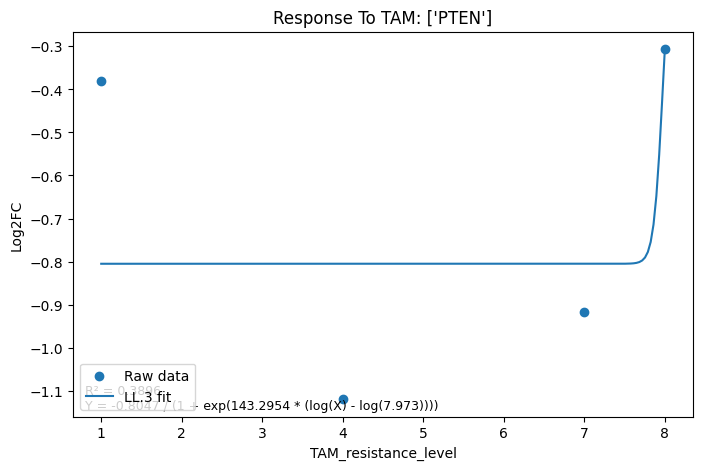

            test_id      gene_id  gene                    locus   sample_1  \
2678    XLOC_002679  XLOC_002679  PTEN  chr10:89623194-89728532  MCF-7S0.5   
27831   XLOC_002679  XLOC_002679  PTEN  chr10:89623194-89728532  MCF-7S0.5   
78137   XLOC_002679  XLOC_002679  PTEN  chr10:89623194-89728532  MCF-7S0.5   
153596  XLOC_002679  XLOC_002679  PTEN  chr10:89623194-89728532  MCF-7S0.5   

        sample_2 status  value_1  value_2  log2(fold_change)  test_stat  \
2678           1     OK  33.7942  25.9717          -0.379835   0.713015   
27831          4     OK  33.7942  15.5636          -1.118600   2.075260   
78137          7     OK  33.7942  17.9128          -0.915788   1.708730   
153596         8     OK  33.7942  27.3204          -0.306796   0.576315   

         p_value   q_value significant  
2678    0.475836  0.999988          no  
27831   0.037963  0.800981          no  
78137   0.087502  0.999988          no  
153596  0.564402  0.999988          no  
R-squared: 0.3896
Model equa

In [109]:
PTEN= ['PTEN']
result_PIP = dose_response_analysis(
    "LL.3",
    PTEN,
    df,
    log_x=False,
    ax=None,
)

## Inspect relationships between two modules

In [ ]:
summarized = (
    module_table.loc[module_table["time"] == 24]
    .groupby(["module", "sample_2"])["log2(fold_change)"]
    .agg(mean_eg="mean", SD_eg="std")
    .reset_index()
)

mean_wide = summarized.pivot(index="sample_2", columns="module", values="mean_eg")
sd_wide = summarized.pivot(index="sample_2", columns="module", values="SD_eg")

x_module = "hRPTECTERT1_50"
y_module = "hRPTECTERT1_264"

plot_data = pd.DataFrame({
    "sample_2": mean_wide.index,
    "x_mean": mean_wide[x_module],
    "y_mean": mean_wide[y_module],
    "x_sd": sd_wide[x_module],
    "y_sd": sd_wide[y_module],
}).dropna()

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    plot_data["x_mean"], plot_data["y_mean"],
    xerr=plot_data["x_sd"], yerr=plot_data["y_sd"],
    fmt="o", capsize=3
)
for _, row in plot_data.iterrows():
    ax.annotate(str(row["sample_2"]), (row["x_mean"], row["y_mean"]))
ax.set(
    title="Increased oxidative stress vs Increased lipid peroxidation",
    xlabel="EGs module 50",
    ylabel="EGs module 264",
)
plt.show()

## Response-response model based on dose-response predictions

In [ ]:
def response_response_from_predictions(
    module_number1,
    module_number2,
    module_model1,
    module_model2,
    key_event1,
    key_event2,
    response_model="modified_W1.4",
    concentrations=(250, 500, 1000),
):
    dr1 = dose_response_analysis(module_number1, 24, module_model1, key_event1)
    dr2 = dose_response_analysis(module_number2, 24, module_model2, key_event2)

    conc = np.asarray(concentrations, dtype=float)
    y1 = predict_model(dr1["model"], conc)
    y2 = predict_model(dr2["model"], conc)
    merged = pd.DataFrame({"sample_2": conc, "Y1": y1, "Y2": y2})

    fitted = fit_nonlinear_model(merged["Y1"], merged["Y2"], model_name=response_model)
    equation = model_equation(response_model, fitted["params"], x_name="Y1", y_name="Y2")

    x_seq = np.linspace(merged["Y1"].min(), merged["Y1"].max(), 200)
    y_curve = predict_model(fitted, x_seq)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(merged["Y1"], merged["Y2"], label="Predicted responses")
    ax.plot(x_seq, y_curve, label=f"{response_model} fit")
    ax.set(title="Modified Response-Response Model", xlabel=key_event1, ylabel=key_event2)
    ax.text(0.02, 0.02, equation, transform=ax.transAxes, fontsize=9)
    ax.legend()
    plt.show()

    return {"model": fitted, "equation": equation, "data": merged, "figure": fig}

## Notes on the conversion

- R's `drc::drm()` has been replaced with `scipy.optimize.curve_fit()`.
- Several functions named `response_response_analysis` were redefined in the original file. They are separated here into clearly named Python functions.
- The original file contained calls to undefined/custom R functions such as `modified_weibull1()` and calls whose argument lists did not match the function definition. The notebook implements a practical shifted Weibull model as `modified_weibull1_4`.
- Nonlinear fitting with only three concentrations can be underdetermined for four- or five-parameter models. More concentration levels or parameter bounds may be needed for stable estimates.